In [ ]:
# 3rd party imports
import logging
import matplotlib.pyplot as plt
import pandas as pd

# Logging setup
logger = logging.getLogger()
logger.handlers.clear()
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.INFO)
logger.addHandler(stream_handler)

# Local imports
from transportation_models.utils.data_processing import PeMSDataProcessor

# Plotting setup
plt.rcParams.update(
    {
        "font.size": 24,  # Default text size (axes labels, titles, etc.)
        "axes.titlesize": 36,  # Title size
        "axes.labelsize": 30,  # X/Y label size
        "xtick.labelsize": 20,  # X tick labels
        "ytick.labelsize": 20,  # Y tick labels
        "legend.fontsize": 20,  # Legend
    }
)

# Data loading
DataProcessor = PeMSDataProcessor(
    root_directory="/Volumes/easystore/work/boulder/Caltrans/PeMS",
    metadata_filepath="/Volumes/easystore/work/boulder/Caltrans/PeMS/metadata/station_metadata_calibrated.csv",
    save_transforms=False
    )
metadata_df = DataProcessor.metadata_df.copy()
metadata_df.set_index("Station ID", inplace=True)
timeseries_df = pd.read_csv("/Volumes/easystore/work/boulder/Caltrans/PeMS/processed_data/data_long.csv")

<Axes: title={'center': 'Normalized Traffic Count Distributions'}, ylabel='Frequency'>

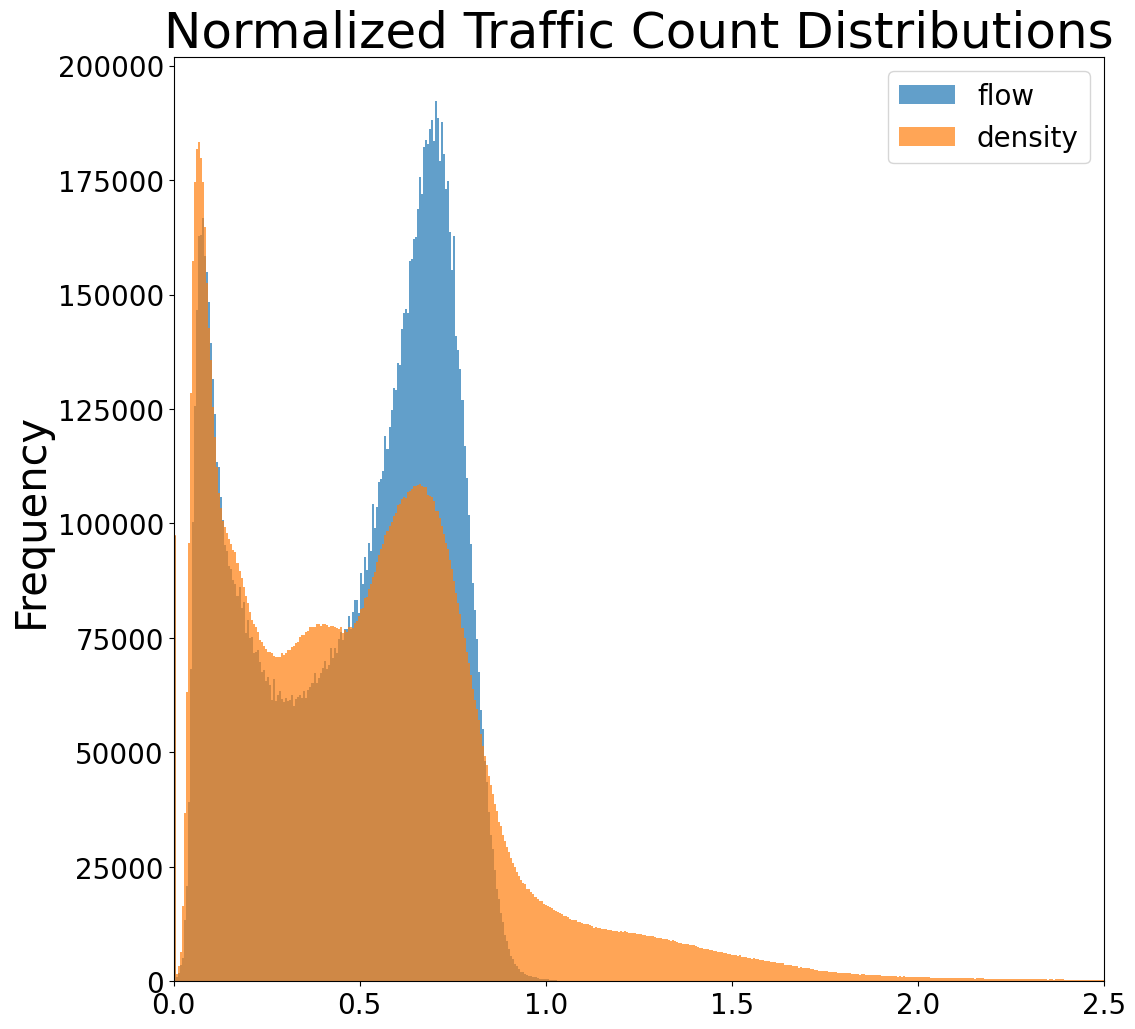

In [2]:
timeseries_df.loc[:, ['flow', 'density']].plot(
    figsize=(12,12),
    subplots=False,
    kind='hist',
    bins=1000,
    alpha=0.7,
    title='Normalized Traffic Count Distributions',
    xlim=[0,2.5],
    )

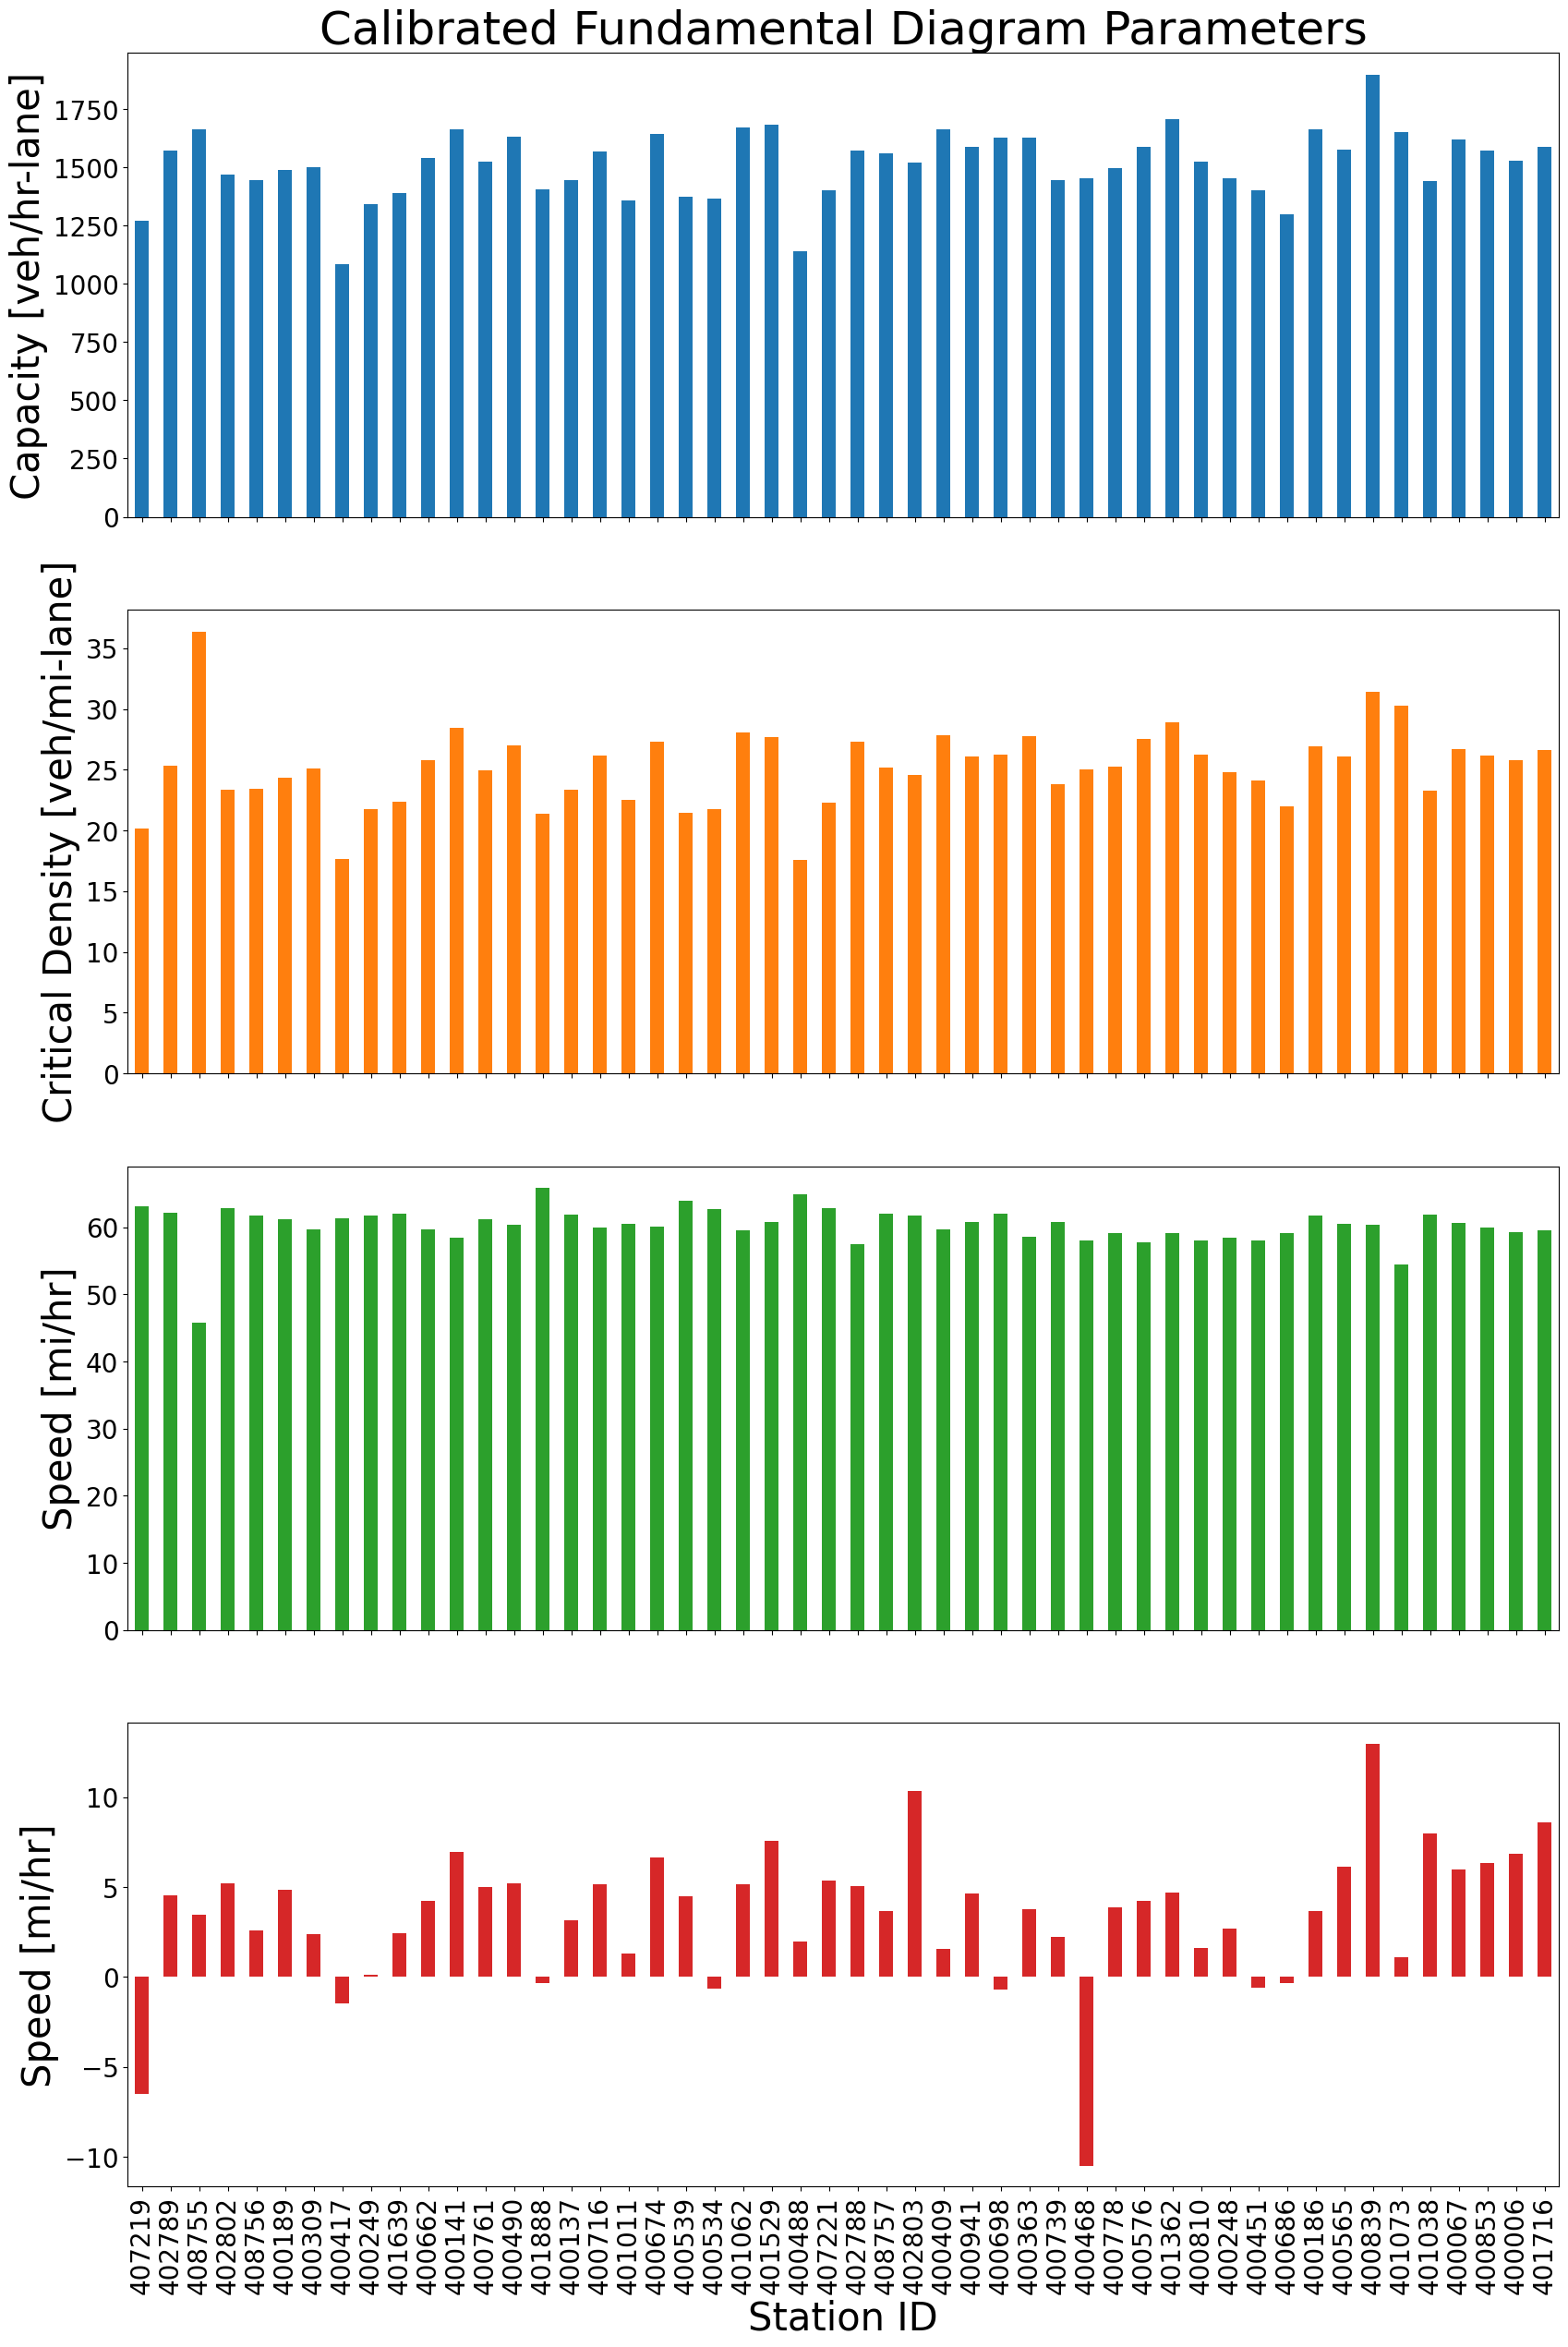

In [11]:
# Slice data
metadata_df = metadata_df.loc[metadata_df['capacity'].notna(), :]
metadata_df = metadata_df.sort_values(by=["Fwy", "Abs PM"])

# Make plots
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(20,30))
metadata_df["capacity"].plot(ax=axes[0], kind='bar', ylabel="Capacity [veh/hr-lane]", color='tab:blue')
metadata_df["critical_density"].plot(ax=axes[1], kind='bar', ylabel="Critical Density [veh/mi-lane]", color='tab:orange')
metadata_df["free_flow_speed"].plot(ax=axes[2], kind='bar', ylabel="Speed [mi/hr]", color='tab:green')
metadata_df["congestion_wave_speed"].plot(ax=axes[3], kind='bar', ylabel="Speed [mi/hr]", color='tab:red')

# Configure plot parameters
axes[0].set_title("Calibrated Fundamental Diagram Parameters")
axes[-1].tick_params(axis='x', rotation=90)

plt.show()